Itération 0 | Coût : 1.3014 | a : 0.0002, b : 0.0000
Itération 100 | Coût : 0.2000 | a : 0.0101, b : 0.0001
Itération 200 | Coût : 0.0660 | a : 0.0136, b : 0.0001
Itération 300 | Coût : 0.0497 | a : 0.0148, b : 0.0001
Itération 400 | Coût : 0.0478 | a : 0.0152, b : 0.0001
Itération 500 | Coût : 0.0475 | a : 0.0154, b : 0.0002
Itération 600 | Coût : 0.0475 | a : 0.0154, b : 0.0002
Itération 700 | Coût : 0.0475 | a : 0.0155, b : 0.0002
Itération 800 | Coût : 0.0475 | a : 0.0155, b : 0.0002
Itération 900 | Coût : 0.0475 | a : 0.0155, b : 0.0002
Itération 1000 | Coût : 0.0475 | a : 0.0155, b : 0.0002


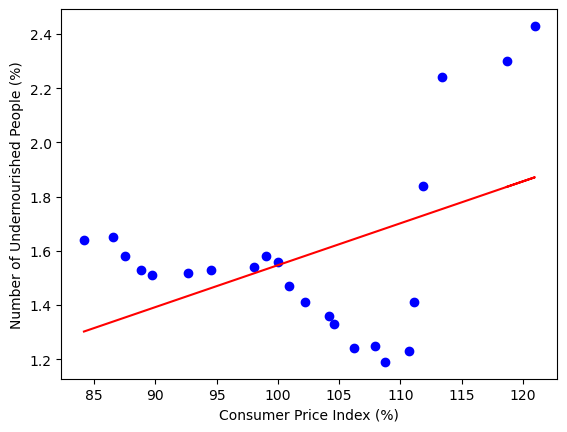

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# chargement du dataset depuis le fichier CSV
data = pd.read_csv("../data/data_nutrition.csv")

# extraction de la feature:
# ici on choisi une seule colonne de notre dataset (CPI)
X = data['Consumer_Price_Index_in_percent'].tolist()

# extraction de la variable cible(target)
# c'est ce qu'on veut prédire : le % de sous-alimentation
Y = data['Number_of_Undernourished_People_in_percent'].tolist()


# fonction de régression linéaire simple avec descente de gradient
def linear_regression_from_scratch(X, Y, alpha=0.000001, iterations=1001):
    
    # a = pente (coefficient de X)
    # b = biais (valeur de base quand X = 0)
    a = 0.0
    b = 0.0
    
    # nombre d'exemples dans le dataset
    m = len(Y)

    # boucle d'apprentissage
    for i in range(iterations):
        
        # prédictions du modèle actuel pour toutes les données
        predictions = [a * X[j] + b for j in range(m)]

        # calcul de l'erreur (fonction coût)
        cout = sum((predictions[j] - Y[j])**2 for j in range(m)) / (2 * m)

        # calcul du gradient pour a (pente)
        da = sum((predictions[j] - Y[j]) * X[j] for j in range(m)) / m

        # calcul du gradient pour b (biais)
        db = sum((predictions[j] - Y[j]) for j in range(m)) / m

        # mise à jour des paramètres par cette formule:
        a = a - alpha * da
        b = b - alpha * db

        # affichage pour suivre l'évolution de l'apprentissage
        if i % 100 == 0:
            print(f"Itération {i} | Coût : {cout:.4f} | a : {a:.4f}, b : {b:.4f}")

    # retour des paramètres appris ainsi que la liste des predictions pour l'utiliser après pour l'affichage du graphique
    return a, b ,predictions


# entraînement du modèle
a, b ,predictions= linear_regression_from_scratch(X, Y)
# affichage des points réels
plt.scatter(X, Y, color='blue', label='Données réelles')

# affichage de la droite de régression apprise par le modèle
plt.plot(X, predictions, color='red', label='Régression linéaire')

# étiquettes des axes
plt.xlabel('Consumer Price Index (%)')
plt.ylabel('Number of Undernourished People (%)')
# affichage du graphique final
plt.show()